<a href="https://colab.research.google.com/github/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/blob/main/Python%20NoteBooks/Clasificaci%C3%B3n_regresi%C3%B3n_logistica_bonomial_danos_al_coraz%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Contexto de los datos

El conjunto de datos trata con información relacionada del sector salud, es información histórica de variables clínicas de pacientes que padecen daños al corazón.

Las variables independientes:

* *BMI*: Indice de masa corporal con valores entre *12.02* y *94.85*.
* *Smoking*: Si la persona es fumadora o no con valores categóritos de *‘Yes’* o *‘No’*.
* *AlcoholDrinking* : Si consume alcohol o no, con valores categóricos de *‘Yes’* o *‘No’*.
* *Stroke*: Si padece alguna anomalía cerebrovascular, apoplejia o algo similar, con valores categóricos de *‘Yes’* o *‘No’*.
* *PhysicalHealth* Estado físico en lo general con valores entre *0* y *30*.
* *MentalHealth*. Estado mental en lo general con valores entre *0* y *30*.
* *DiffWalking* . Que si se le dificulta caminar o tiene algún padecimiento al caminar, con valores categóritoc de *‘Yes’* o *‘No’*.
* *Sex*: Género de la persona, con valores de *‘Female’* y *‘Male’* para distinguir al género femenino y masculino respectivamente.
* *AgeCategory*: Una clasificación de la edad de la persona de entre *18* y *80* años. La primera categoría con un rango de edad entre *18-24*, a partir de *25* con rangos de *5* en *5* hasta la clase de *75-80* y una última categoría mayores de *80* años.
* *Race*. Raza u origen de la persona con valores categóricos de *‘American Indian/Alaskan Native’, ’Asian’,’Black’, ’Hispanic’, ’Other’ y’White’*.
* *Diabetic*. Si padece o ha padecido de diabetes en cuatro condiciones siendo *Yes* y *No*  *‘borderline diabetes Yes’ condición antes de detectarse diabetes tipo 2, y *‘Yes (during pregnancy)’* durante embarazo.
* *PhysicalActivity* que si realiza actividad física, con valores categóricos de *‘Yes’* o *‘No’*.
* *GenHealth*: Estado general de salud de la persona con valores categóricos de *‘Excellent’*, *‘Very good’*, *‘Good’*, *‘Fair’* y *‘Poor’* con significado en español de excelente, muy buena, buena, regular y pobre o deficiente.
* *SleepTime*: valor numérico de las horas de sueño u horas que duerme la persona con valores en un rango entre *1* y *24*.
* *Asthma*: si padece de asma o no, con valores categóricos de *Yes’* o *‘No’*.
* *KidneyDisease*: si tiene algún padecimiento en los riñones, con valores categóricos de *‘Yes’* o *‘No’*.
* *SkinCancer*: si padece algún tipo de cáncer de piel, con valores categóricos de *‘Yes’* o *‘No’*.

La variable de interés como dependiente o variable de salida es la de daño al corazón (*HeartDisease*), con valores categóricos de *‘Yes’* o *‘No’*.

El caso de estudio puede encontrarse en *google collab* en el elnace https://colab.research.google.com/drive/1UksxtO4wthQzbMJZ3CApB8I4cNNSwSIg?usp=sharing .


De igual forma, el caso de estudio se puede encontrar en el en la dirección *url* https://github.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/blob/main/Python%20NoteBooks/Clasificaci%C3%B3n_regresi%C3%B3n_logistica_bonomial_danos_al_coraz%C3%B3n.ipynb .

Los datos se pueden encontrar en el espacio del autor *github.com* https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/datos/muestra10000_danios_al_corazon2026.csv. Los datos son una muestra de *10000* registros y *18* variables.

Las funciones se pueden encontrar y reutilizar desde el espacio *github.com* https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/Python%20NoteBooks/funciones/Funciones%20para%20implementar%20y%20evaluar%20REGRESION%20LOGISTICA.py



# Objetivo

Construir y evaluar modelos de regresión logística binaria para datos daños de corazón.

Para construir el modelo de regresión loística, los datos originales no se escalan ni se estandarizan, solo se transforman con variables *dummys*, con ello se construyen los modeos de regresión logística tanto con datos desbalanceados y aplicando técnicas de balanceo de datos como *undersamplig*, *ovesamplig*, *SMOTE* y ponderación.

Las particiones serán aleatoriamente *70%* para datos de entrenamiento y *30%* para datos de validación.

Se presenta y describe la matriz de confusión para todos los modelos de regresión logística construidos

La evaluación se hace con las métricas de exactitud, precisión sensibilidad, *F1 Score* y el estadístico *Kappa* que se extraen de la matriz de confusión.

Al final, se deberá interpretar los estadísticos de la evaluación de modelos creados e indicar y justificar el por qué un modelo tiene mejor rendimiento que otro en términos de calidad predictiva.

# Descripción


## Cargar librerías


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
# from sklearn.linear_model import LassoCV
# from sklearn.linear_model import RidgeCV
from sklearn.metrics import ( mean_squared_error,
    mean_absolute_error,  r2_score )

from scipy.stats import shapiro
from scipy.stats import kstest
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import linear_reset
import statsmodels.api as sm

# Para validar posutalados
from statsmodels.stats.outliers_influence import (
    variance_inflation_factor)
from statsmodels.stats.diagnostic import (het_breuschpagan,
    linear_reset)
from statsmodels.stats.stattools import ( durbin_watson)
from scipy.stats import ( shapiro)
from scipy.stats import shapiro
from scipy.stats import kstest
from scipy.stats import anderson
from sklearn.linear_model import (  LassoCV)
from sklearn.linear_model import (  RidgeCV)
from sklearn.preprocessing import (PolynomialFeatures)
from sklearn.svm import SVR # Para modelos SVR

# Para arboles de regresión y bosques aleatorios
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import plot_tree

## Cargar funciones



In [2]:
url = "https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/Python%20NoteBooks/funciones/Funciones%20para%20implementar%20y%20evaluar%20REGRESION%20LOGISTICA.py"
import requests

exec(requests.get(url).text)

## Cargar datos


In [3]:
url = "https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/datos/muestra10000_danios_al_corazon2026.csv"
datos = f_cargar_datos(url)

## Visualizar datos


In [4]:
f_visualizar_head_tail_reducido(datos)

,BMI,Smoking,AlcoholDrinking,Stroke,...,Asthma,KidneyDisease,SkinCancer,HeartDisease
0,46.11,Yes,No,No,...,No,No,No,No
1,28.29,No,No,No,...,No,No,No,No
2,42.93,No,No,No,...,No,No,No,No
3,26.61,No,No,No,...,No,No,No,No
4,40.69,No,No,No,...,No,No,No,No
5,23.11,No,No,No,...,No,No,No,No
6,...,...,...,...,...,...,...,...,...
7,35.28,No,No,No,...,No,No,No,No
8,24.34,No,No,No,...,Yes,No,No,No
9,19.94,No,No,No,...,No,No,No,No


## Estadísticos descriptivos

Los estadísticos descriptivos se muestran con la función *f_describir_datos()* en modo consola.

Ejecutando la función *f_frecuencias_clases()* que despliega la visualización gráfica de la frecuencia de clases de los datos categóricos, y poniendo atención especialmente a la variable dependiente *HeartDisease*, abajo a la derecha, se observa que hay un desbalance de clases, con el *91.04%* para valores no enfermos en relación al *8.96%* para pacientes enfermos.

Lo anterior presupone que las predicciones tienden a estimar muchos casos de pacientes no enfermos, por lo que hay que aplicar técnicas de balanceo de clases en la construccón de modelos de clasificación, como el de regresión logística binomial de este caso de estudio.

In [5]:
f_describir_datos(datos)

{'describe':                   count     mean     std    min    25%    50%    75%    max
 BMI             10000.0  28.2919  6.3751  12.48  23.91  27.32  31.38  94.66
 PhysicalHealth  10000.0   3.5092  8.1639   0.00   0.00   0.00   2.00  30.00
 MentalHealth    10000.0   4.0102  8.1181   0.00   0.00   0.00   3.00  30.00
 SleepTime       10000.0   7.0881  1.4222   1.00   6.00   7.00   8.00  20.00,
 'frecuencias': {'Smoking':          Frecuencia  Porcentaje
  Smoking                        
  No             5860        58.6
  Yes            4140        41.4,
  'AlcoholDrinking':                  Frecuencia  Porcentaje
  AlcoholDrinking                        
  No                     9306       93.06
  Yes                     694        6.94,
  'Stroke':         Frecuencia  Porcentaje
  Stroke                        
  No            9617       96.17
  Yes            383        3.83,
  'DiffWalking':              Frecuencia  Porcentaje
  DiffWalking                        
  No             

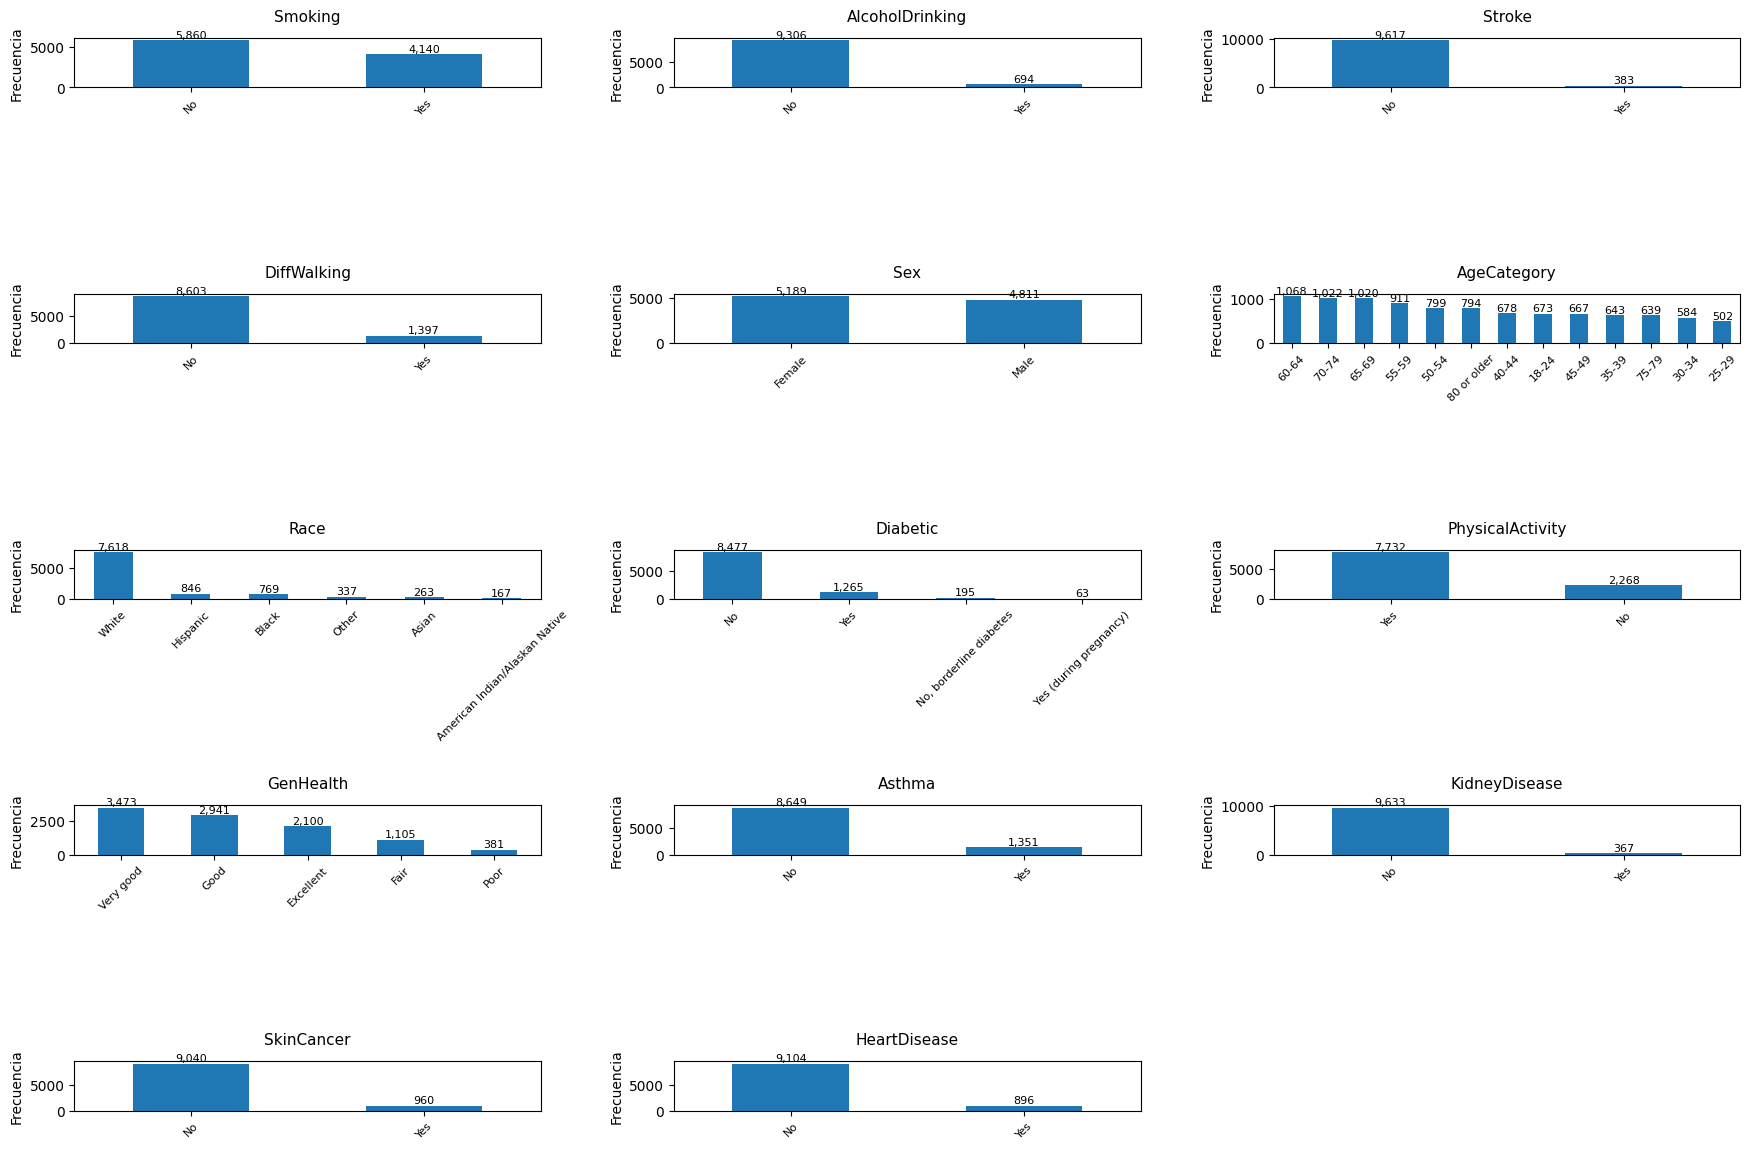

In [6]:
f_frecuencias_clases(datos)

## Transformar a variables dummys

Se transforman las variables categóricas con la función *f_convertir_dummys()* a variables *dummys*, ahora todas la variables categóricas tienen valores numéricos de acuerdo a los valores, sobre todo, la variable dependiente *HeartDisease*, tiene valores *0* para *'No'* enfermo y *1* para *'Yes'* o si enfermo.

Al construir variables *dummys* en el conjunto de datos, se modifican los nombres de variable de acuerdo a la mayor frecuencia de clase, la función devuelve los datos transforamados con los nombres cambirenombrados, de tal forma que ahora la variable dependietne se llama *HeartDisease_yes*.

Además, cuando hay clases multinomiales, se crean columnas por cada clase, lo que conlleva a tener ahora *38* columnas en el conjunto de datos transformados.

Esto decodificación, permite en *Python* construir los modelos de clasificación de manera mas amigable.

In [21]:
datos_transformados = f_convertir_dummys(datos)
f_visualizar_head_tail_reducido(datos_transformados)



 CONVERSIÓN A VARIABLES DUMMY 
Variables originales : 18
Variables finales    : 38
Observaciones        : 10000


,BMI,PhysicalHealth,MentalHealth,SleepTime,...,Asthma_Yes,KidneyDisease_Yes,SkinCancer_Yes,HeartDisease_Yes
0,46.11,0,0,8,...,0,0,0,0
1,28.29,5,3,7,...,0,0,0,0
2,42.93,0,0,6,...,0,0,0,0
3,26.61,0,0,6,...,0,0,0,0
4,40.69,0,0,7,...,0,0,0,0
5,23.11,0,20,3,...,0,0,0,0
6,...,...,...,...,...,...,...,...,...
7,35.28,0,0,7,...,0,0,0,0
8,24.34,1,7,8,...,1,0,0,0
9,19.94,1,0,8,...,0,0,0,0


# Desarrollo


## Datos de entrenamiento y datos de validación

Con la función *f_particionar_datos()* se crean los conjuntos datos de entrenamiento con el *70%* y el *30%* para datos validación respectivamente.


Datos de entrenamiento:

In [22]:
particiones = f_particionar_datos(datos_transformados)
datos_entrenamiento = particiones["datos_entrenamiento"]
datos_validacion = particiones["datos_validacion"]
f_visualizar_head_tail_reducido(datos_entrenamiento)

,BMI,PhysicalHealth,MentalHealth,SleepTime,...,Asthma_Yes,KidneyDisease_Yes,SkinCancer_Yes,HeartDisease_Yes
0,28.62,30,30,6,...,0,1,0,0
1,34.18,0,2,6,...,0,0,0,0
2,24.8,0,0,7,...,0,0,0,0
3,24.41,30,30,3,...,0,0,0,0
4,20.34,0,0,7,...,0,0,0,0
5,22.67,2,1,9,...,0,0,0,0
6,...,...,...,...,...,...,...,...,...
7,25.11,0,0,7,...,1,0,0,0
8,24.18,1,0,6,...,0,0,0,0
9,19.37,0,0,7,...,0,0,0,0


Datos de validación:

In [23]:
f_visualizar_head_tail_reducido(datos_validacion)

,BMI,PhysicalHealth,MentalHealth,SleepTime,...,Asthma_Yes,KidneyDisease_Yes,SkinCancer_Yes,HeartDisease_Yes
0,29.35,2,20,8,...,0,0,0,0
1,26.58,1,0,6,...,0,0,0,0
2,24.37,30,0,8,...,0,0,0,0
3,28.84,5,1,8,...,1,0,0,0
4,19.77,0,0,7,...,0,0,0,0
5,20.25,0,0,9,...,0,0,0,0
6,...,...,...,...,...,...,...,...,...
7,30.38,0,0,8,...,0,0,0,1
8,26.09,0,3,7,...,0,0,0,0
9,25.56,0,1,8,...,0,0,0,0


## Modelo regresión logística binomial

Se crea el modelo de regresión logística binomial (*RLB*) con los datos de entrenamiento ejecutando la función *f_crear_modelo_RLB()*, a quien se le indica el nombre de la variable dependiente que con la transformación a variables *dummys* ahora se llama *HeartDisease_Yes*.






In [24]:
modelo_RLB = f_crear_modelo_regresion_logistica(
    datos = datos_entrenamiento,
    variable_dependiente = "HeartDisease_Yes",
    tipo="binomial",
)



 REGRESIÓN LOGÍSTICA 
Tipo               : binomial
Balanceo           : ninguno
Variable objetivo  : HeartDisease_Yes
Número de clases   : 2

Frecuencias originales:
{0: 6397, 1: 603}

Frecuencias entrenamiento:
{0: 6397, 1: 603}

Observaciones usadas: 7000


### Predicciones de RLB

Con el modelo *modelo_RLB* se hacen predicciones usando los datos de validación con la función *f_predicciones()*.

Las prediccones incluyen el valor real, el valor de predicción y la probabilidad de que se de ese valor.

Lo anterior permite construir la matriz de confusión para extraer los estadísticos que sirven para evaluar la calidad predictiva del modelo.



In [25]:
predicciones_RLB = f_predicciones(
    modelo_RLB,
    datos_validacion,
    "HeartDisease_Yes"
)
predicciones_RLB

,Real,Prediccion,Probabilidad,Porcentual
0,0,0,0.0594,5.94 %
1,0,0,0.0451,4.51 %
2,0,0,0.0078,0.78 %
3,0,0,0.0390,3.9 %
4,0,0,0.0468,4.68 %
...,...,...,...,...
2995,0,0,0.0164,1.64 %
2996,0,0,0.0065,0.65 %
2997,0,0,0.3489,34.89 %
2998,0,0,0.2533,25.33 %


### Matriz de confusión

Con la función *f_matriz_confusion()*, se crea la matriz de confusión, la salida en modo consola; se observa que el valor de exactitud predictiva del modelo está alrededor del *90%* sin embargo,  estadísticos como *Kappa* con valor de *0.1234*, de sensibilidad o *Recall* de *0.0853* e inclusive de *F1-Score* de *0.1471* hacen dudar de la eficiencia del modelo.

Lo anterior se debe a que se construyó el modelo con datos desbalanceados, lo que permite y da lugar para aplacar técnicas de balanceo de datos.




In [26]:
f_matriz_confusion(
    modelo_RLB,
    datos_validacion,
    "HeartDisease_Yes"
)

{'matriz_confusion':         Pred_0  Pred_1
 Real_0    2685      22
 Real_1     268      25,
 'estadisticos':    Accuracy   Kappa  Precision  Recall      F1  Balanced_Accuracy
 0    0.9033  0.1234     0.5319  0.0853  0.1471             0.5386}

### Curva ROC



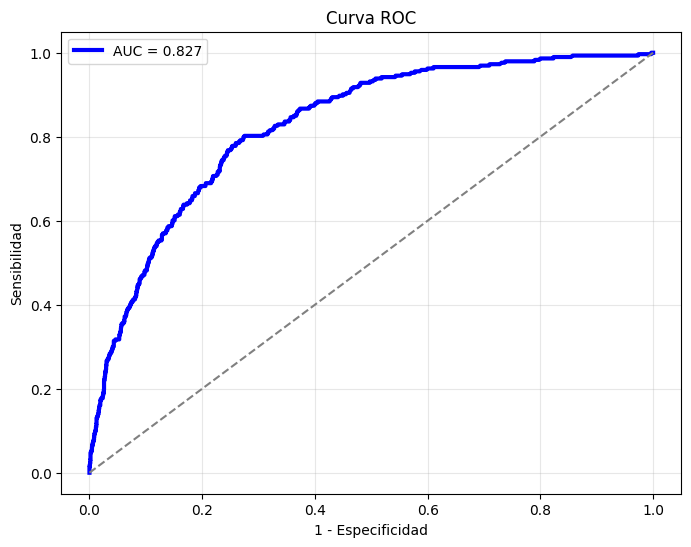

0.8270133934143689


,Umbral,FPR,TPR
0,inf,0.000000,0.000000
1,0.8153,0.000000,0.003413
2,0.8053,0.000000,0.013652
3,0.7663,0.000369,0.013652
4,0.7620,0.000369,0.017065
5,0.7454,0.000739,0.017065
6,0.7270,0.000739,0.020478
7,0.7158,0.001108,0.020478
8,0.6975,0.001108,0.023891
9,0.6830,0.001478,0.023891


In [27]:
tabla_ROC, AUC = f_visualizar_ROC(
    predicciones_RLB
)

print(AUC)

tabla_ROC.head(20)

## Balance de clase

Se utilizan las técnicas *unsamplig*, *oversampling*, *SMOTE* y ponderación como estrategias para tratar con clases desbalanceadas y generar modelos de regresión logística con estas técnicas.

### Undersamplig

In [28]:
modelo_RLB_US = f_crear_modelo_regresion_logistica(
        datos = datos_entrenamiento,
        variable_dependiente = "HeartDisease_Yes",
        tipo="binomial",
        balanceo="undersampling",
        semilla=2026)





 REGRESIÓN LOGÍSTICA 
Tipo               : binomial
Balanceo           : undersampling
Variable objetivo  : HeartDisease_Yes
Número de clases   : 2

Frecuencias originales:
{0: 6397, 1: 603}

Frecuencias entrenamiento:
{0: 603, 1: 603}

Observaciones usadas: 1206


### Oversampling


In [17]:
modelo_RLB_OS = f_crear_modelo_regresion_logistica(
        datos = datos_entrenamiento,
        variable_dependiente = "HeartDisease_Yes",
        tipo="binomial",
        balanceo="oversampling",
        semilla=2026)


 REGRESIÓN LOGÍSTICA 
Tipo               : binomial
Balanceo           : oversampling
Variable objetivo  : HeartDisease_Yes
Número de clases   : 2

Frecuencias originales:
{0: 6397, 1: 603}

Frecuencias entrenamiento:
{1: 6397, 0: 6397}

Observaciones usadas: 12794


### SMOTE


In [18]:
modelo_RLB_SMOTE = f_crear_modelo_regresion_logistica(
        datos = datos_entrenamiento,
        variable_dependiente = "HeartDisease_Yes",
        tipo="binomial",
        balanceo="SMOTE",
        semilla=2026)


 REGRESIÓN LOGÍSTICA 
Tipo               : binomial
Balanceo           : SMOTE
Variable objetivo  : HeartDisease_Yes
Número de clases   : 2

Frecuencias originales:
{0: 6397, 1: 603}

Frecuencias entrenamiento:
{0: 6397, 1: 6397}

Observaciones usadas: 12794


### Ponderación


In [19]:
modelo_RLB_PONDERA = f_crear_modelo_regresion_logistica(
        datos = datos_entrenamiento,
        variable_dependiente = "HeartDisease_Yes",
        tipo="binomial",
        balanceo="ponderacion",
        semilla=2026)


 REGRESIÓN LOGÍSTICA 
Tipo               : binomial
Balanceo           : ponderacion
Variable objetivo  : HeartDisease_Yes
Número de clases   : 2

Frecuencias originales:
{0: 6397, 1: 603}

Frecuencias entrenamiento:
{0: 6397, 1: 603}

Observaciones usadas: 7000


## Evaluación de modelos

Con los modelos creados, se hace la evaluación de modelos usando la función *f_evaluación()* con los argumentos de cada modelo.

Los resultados en modo consola indican que habiendo aplicado técnicas de balanceo de clases, disminuye el estadístico de *accuracy* pero aumentan los estadísticos como sensibilidad, *Kappa*, entre otros, de tal manera que estos modelos que aplican técnicas de balanceo ofrecen mejor calidad predicitva tanto para pacientes enfermos como no enfermos.



In [20]:
evaluacion = f_evaluacion(

    modelos=[modelo_RLB,
        modelo_RLB_US,
        modelo_RLB_OS,
        modelo_RLB_SMOTE,
        modelo_RLB_PONDERA],

    datos_validacion=[datos_validacion,
        datos_validacion,
        datos_validacion,
        datos_validacion,
        datos_validacion],

    variable_dependiente=
        "HeartDisease_Yes",

    clase_interes=
        1,

    nombres_modelos=["Original",
        "Undersampling",
        "Oversampling",
        "SMOTE",
        "Ponderado"]
)

evaluacion

,Modelo,Balanceo,Accuracy,Kappa,Precision,Recall,F1,Balanced_Accuracy
0,Original,ninguno,0.9033,0.1234,0.5319,0.0853,0.1471,0.5386
1,Undersampling,undersampling,0.7440,0.2444,0.2358,0.7235,0.3557,0.7349
2,Oversampling,oversampling,0.7503,0.2590,0.2444,0.7440,0.3679,0.7475
3,SMOTE,SMOTE,0.7927,0.1326,0.1879,0.3379,0.2415,0.5899
4,Ponderado,ponderacion,0.7543,0.2697,0.2506,0.7611,0.3770,0.7573


# Interpretación del caso de estudio

El caso de estudio cumple con el objetivo planteado al inicio del mismo.

Se construyeron modelos de clasificación utilizando el algoritmo de regresión logística binaria.

Los datos fueron particionados 70% para datos de entrenamiento y 30% para datos de validación.

Las variables categóricas incluyendo la variable dependiente, fueron transformadas a variables dummys, lo que permitió utilizar las funciones para crear modelos de regresión logística binaria con datos desbalanceados.

Posteriormente se crearon modelos alternativos pero con datos balanceados aplicando técnicas como undersampling, oversampling, SMOTE y ponderación de la variable clase.

Al final se tiene una evaluación de los distintos modelos llegando a la conclusión de que el mejor modelo aplicado es el modelo de regresión logística binaria con la técnica de SMOTE para estos datos desbalanceados.

Los resultados que ofrece la evaluación de modelos son similares a los que ofrece R.

Para el lector, este caso de estudio sirve como una guía para aplicarlo con sus propios datos y reutilizar las funciones aquí presentadas.
